In [1]:
!pip -q install diffusers transformers accelerate safetensors insightface onnxruntime opencv-python pillow matplotlib

In [2]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from insightface.app import FaceAnalysis

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

GENDER = "man"

BASE_MODEL = "SG161222/Realistic_Vision_V5.1_noVAE"

OUTPUT_DIR = "lab8_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Device:", DEVICE)

Device: cuda


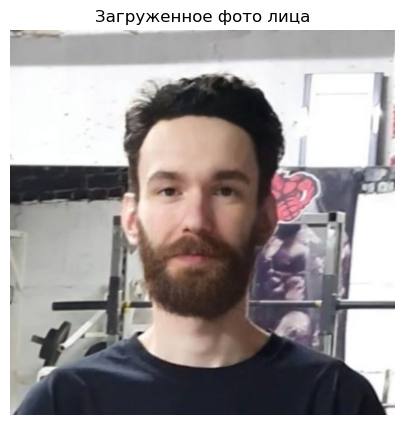

In [4]:
face_photo_path = "my_face.png"
face_image = Image.open(face_photo_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(face_image)
plt.axis("off")
plt.title("Загруженное фото лица")
plt.show()

In [5]:
face_app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

face_app.prepare(
    ctx_id=0 if DEVICE == "cuda" else -1,
    det_size=(640, 640)
)

image_bgr = cv2.cvtColor(np.array(face_image), cv2.COLOR_RGB2BGR)
faces = face_app.get(image_bgr)

if len(faces) == 0:
    raise ValueError("Лицо не найдено. Загрузи более четкое фото анфас.")

faces = sorted(
    faces,
    key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]),
    reverse=True
)

face = faces[0]

face_embedding = torch.from_numpy(face.normed_embedding).to(device=DEVICE, dtype=DTYPE)

face_embedding = face_embedding.unsqueeze(0).unsqueeze(0)

negative_face_embedding = torch.zeros_like(face_embedding)

faceid_embeds = torch.cat([negative_face_embedding, face_embedding], dim=0)

print("face_embedding shape:", face_embedding.shape)
print("faceid_embeds shape:", faceid_embeds.shape)

c:\Users\artem\miniconda3\envs\lab1\lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\artem/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\artem/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\artem/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\artem/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\artem/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

In [6]:
pipe = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL,
    torch_dtype=DTYPE,
    safety_checker=None,
    requires_safety_checker=False
).to(DEVICE)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type="dpmsolver++",
    final_sigmas_type="sigma_min"
)

pipe.load_ip_adapter(
    "h94/IP-Adapter-FaceID",
    subfolder="",
    weight_name="ip-adapter-faceid_sd15.bin",
    image_encoder_folder=None
)

pipe.set_ip_adapter_scale(0.75)

print("Pipeline loaded")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

image_encoder is not loaded since `image_encoder_folder=None` passed. You will not be able to use `ip_adapter_image` when calling the pipeline with IP-Adapter.Use `ip_adapter_image_embeds` to pass pre-generated image embedding instead.
PEFT backend is required to load these weights.


Pipeline loaded


In [7]:
def generate_image(prompt, filename, seed=42, steps=35, guidance_scale=7.0):
    generator = torch.Generator(device=DEVICE).manual_seed(seed)

    image = pipe(
        prompt=prompt,
        ip_adapter_image_embeds=[faceid_embeds],
        num_inference_steps=steps,
        guidance_scale=guidance_scale,
        generator=generator,
        width=512,
        height=768
    ).images[0]

    save_path = os.path.join(OUTPUT_DIR, filename)
    image.save(save_path)

    return image, save_path

In [8]:
prompts = [
    f"{GENDER} in a forest, high quality, realism",
    f"{GENDER} in a city, high quality, realism",
    f"{GENDER} in a beach, high quality, realism",
    f"{GENDER} in cyberpunk city, neon lights, high quality, realism, detailed face",
    f"{GENDER} made of polished metal, cinematic portrait, high quality, realism, detailed face",
    f"{GENDER} in a futuristic studio, dramatic lighting, high quality, realism, detailed face"
]

for i, prompt in enumerate(prompts, 1):
    print(f"{i}. {prompt}")

1. man in a forest, high quality, realism
2. man in a city, high quality, realism
3. man in a beach, high quality, realism
4. man in cyberpunk city, neon lights, high quality, realism, detailed face
5. man made of polished metal, cinematic portrait, high quality, realism, detailed face
6. man in a futuristic studio, dramatic lighting, high quality, realism, detailed face


In [9]:
generated = []

for i, prompt in enumerate(prompts, 1):
    image, path = generate_image(
        prompt=prompt,
        filename=f"result_{i}.png",
        seed=100 + i,
        steps=35,
        guidance_scale=7.0
    )

    generated.append((prompt, image, path))
    print(f"Saved: {path}")

  0%|          | 0/35 [00:00<?, ?it/s]

Saved: lab8_results\result_1.png


  0%|          | 0/35 [00:00<?, ?it/s]

Saved: lab8_results\result_2.png


  0%|          | 0/35 [00:00<?, ?it/s]

...

Saved: lab8_results\result_4.png


  0%|          | 0/35 [00:00<?, ?it/s]

Saved: lab8_results\result_5.png


  0%|          | 0/35 [00:00<?, ?it/s]

Saved: lab8_results\result_6.png


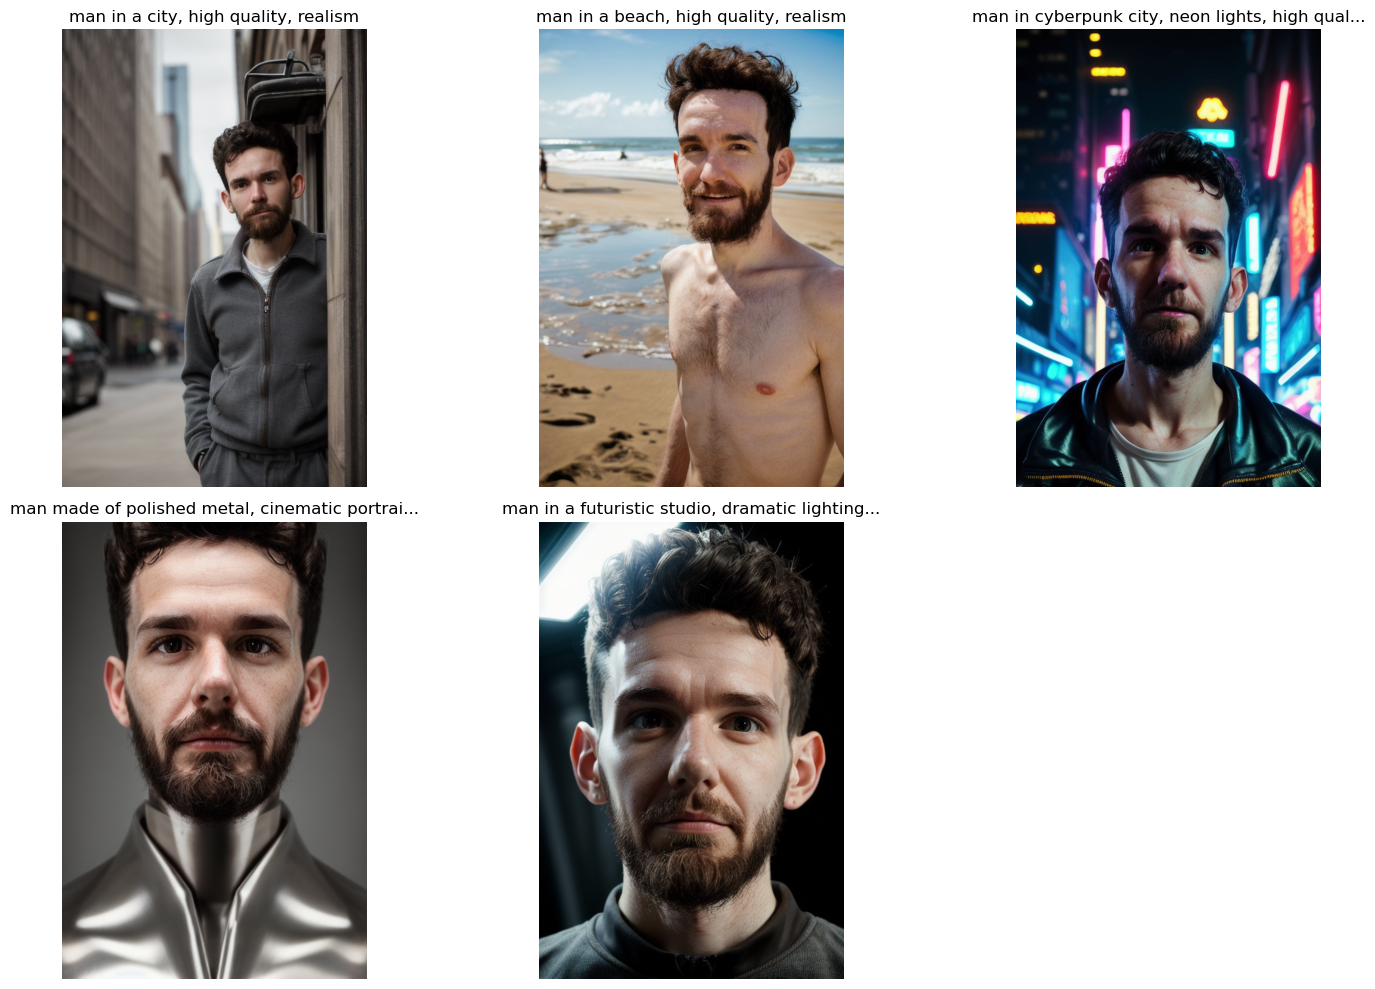

In [11]:
other_images = [
    item for idx, item in enumerate(generated)
    if idx != best_index
]

plt.figure(figsize=(15, 10))

for i, (prompt, image, path) in enumerate(other_images, 1):
    plt.subplot(2, 3, i)
    plt.imshow(image)
    plt.axis("off")
    plt.title(prompt[:45] + ("..." if len(prompt) > 45 else ""))

plt.tight_layout()
plt.show()